# Breast Cancer Classification Using Stacking Ensemble

## Objective

The goal of this project is to build a classification model that predicts whether a tumor is Malignant or Benign using machine learning.

Three Level-0 (Base) models are trained:

1. Logistic Regression
2. Perceptron
3. Decision Tree

Then, a Level-1 Meta Model (Logistic Regression) combines their predictions using Stacking Ensemble.

The models are evaluated using:

- F1-score
- AUC

In [1]:
# Data manipulation

import pandas as pd
import numpy as np


# Visualization

import matplotlib.pyplot as plt
import seaborn as sns


# Preprocessing

from sklearn.preprocessing import LabelEncoder, StandardScaler


# Data splitting and Cross Validation

from sklearn.model_selection import train_test_split, cross_val_predict


# Machine Learning Models

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier


# Evaluation

from sklearn.metrics import (
    f1_score,
    roc_auc_score,
   
)

In [2]:
# Load dataset
df = pd.read_csv("breast-cancer.csv")

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [5]:
df.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
418,906024,B,12.70,12.17,80.88,495.0,0.08785,0.05794,0.023600,0.02402,...,13.65,16.92,88.12,566.9,0.13140,0.16070,0.09385,0.08224,0.2775,0.09464
207,879830,M,17.01,20.26,109.70,904.3,0.08772,0.07304,0.069500,0.05390,...,19.80,25.05,130.00,1210.0,0.11110,0.14860,0.19320,0.10960,0.3275,0.06469
226,88147101,B,10.44,15.46,66.62,329.6,0.10530,0.07722,0.006643,0.01216,...,11.52,19.80,73.47,395.4,0.13410,0.11530,0.02639,0.04464,0.2615,0.08269
266,8910251,B,10.60,18.95,69.28,346.4,0.09688,0.11470,0.063870,0.02642,...,11.88,22.94,78.28,424.8,0.12130,0.25150,0.19160,0.07926,0.2940,0.07587
38,855133,M,14.99,25.20,95.54,698.8,0.09387,0.05131,0.023980,0.02899,...,14.99,25.20,95.54,698.8,0.09387,0.05131,0.02398,0.02899,0.1565,0.05504


In [6]:
df.shape

(569, 32)

In [7]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

In [8]:
#Statistical Summary
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Exploratory Data Analysis (EDA)

In [9]:
# Check missing values
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [10]:
# Count duplicate rows if the same paitent appears morethan once
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [12]:
df["diagnosis"].unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

In [13]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

*Visualize Class Distribution*

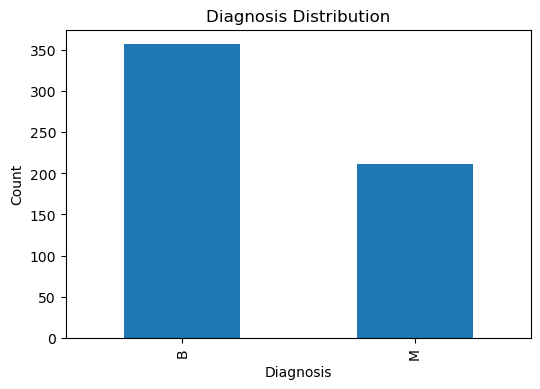

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

df["diagnosis"].value_counts().plot(
    kind="bar"
)

plt.title("Diagnosis Distribution")

plt.xlabel("Diagnosis")

plt.ylabel("Count")

plt.show()

**EDA Observations**

- The dataset contains 569 samples and 32 columns.
- No missing values were found.
- Duplicate rows were checked.
- The target variable contains two classes: Malignant and Benign.
- The dataset is slightly imbalanced.


## Data Preprocessing

In [16]:
# Create a backup copy

df_copy = df.copy()

In [17]:
# Drop patient ID column

df = df.drop("id", axis=1)

*Encode Target Variable*

In [16]:
# Create encoder
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()


# Convert diagnosis into numbers

df["diagnosis"] = encoder.fit_transform(
    df["diagnosis"]
)

In [19]:
#check encoding 
df["diagnosis"].head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

In [20]:
#chek classes
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

**Separate Features and Target**

In [17]:
# Features
import pandas as pd
X = df.drop(
    "diagnosis",
    axis=1
)


# Target

y = df["diagnosis"]

In [22]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


# Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(455, 31)
(114, 31)
(455,)
(114,)


# Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler
# Create scaler

scaler = StandardScaler()


# Fit only on training data

X_train_scaled = scaler.fit_transform(
    X_train
)


# Transform test data

X_test_scaled = scaler.transform(
    X_test
)

## Train Level-0 Base Models

**Logistic Regression ( Model 1)**

In [26]:
#creat the model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [27]:
#Train Logistic Regression
lr_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [28]:
#make prediction
lr_pred = lr_model.predict(
    X_test_scaled
)

In [29]:
#probablity prediction
lr_prob = lr_model.predict_proba(
    X_test_scaled
)[:,1]

**Evaluate Logistic regression**

In [30]:
#F1-Score
lr_f1 = f1_score(
    y_test,
    lr_pred
)

print("Logistic Regression F1:", lr_f1)

Logistic Regression F1: 0.9512195121951219


In [31]:
#AUC
lr_auc = roc_auc_score(
    y_test,
    lr_prob
)

print("Logistic Regression AUC:", lr_auc)

Logistic Regression AUC: 0.996031746031746


***Perceptron (Model2)***

In [32]:
#Creat perceptron
per_model = Perceptron(
    max_iter=1000,
    random_state=42
)

In [33]:
#Train Perceptron
per_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",42


In [34]:
#Make prediction
per_pred = per_model.predict(
    X_test_scaled
)

In [35]:
#getting scores for AUC
per_score = per_model.decision_function(
    X_test_scaled
)

***Evaluate Perceptron***

In [36]:
#F1_Score
per_f1 = f1_score(
    y_test,
    per_pred
)

print("Perceptron F1:", per_f1)

Perceptron F1: 0.963855421686747


In [37]:
#AUC
per_auc = roc_auc_score(
    y_test,
    per_score
)

print("Perceptron AUC:", per_auc)

Perceptron AUC: 0.9910714285714286


***Decision Tree (Model 3)***

In [38]:
#creat decision tree
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [39]:
#Train decision tree
dt_model.fit(
    X_train,
    y_train
)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [40]:
#make prediciton
dt_pred = dt_model.predict(
    X_test
)

In [41]:
#probablity
dt_prob = dt_model.predict_proba(
    X_test
)[:,1]

***Evaluate Decision tree***

In [43]:
#F1_Score
dt_f1 = f1_score(
    y_test,
    dt_pred
)

print("Decision Tree F1:", dt_f1)

Decision Tree F1: 0.9047619047619048


In [44]:
#AUC
dt_auc = roc_auc_score(
    y_test,
    dt_prob
)

print("Decision Tree AUC:", dt_auc)

Decision Tree AUC: 0.9246031746031745


## Generate Out-of-Fold (OOF) Predictions

**Logistic Regression OOF Predictions**

In [45]:
lr_oof = cross_val_predict(
    lr_model,
    X_train_scaled,
    y_train,
    cv=5,
    method="predict_proba"
)[:,1]

**Perceptron OOF Predictions**

In [46]:
per_oof = cross_val_predict(
    per_model,
    X_train_scaled,
    y_train,
    cv=5,
    method="decision_function"
)

**Decision Tree OOF Predictions**

In [47]:
dt_oof = cross_val_predict(
    dt_model,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)[:,1]

In [48]:
#Check oof sizes
print(lr_oof.shape)

print(per_oof.shape)

print(dt_oof.shape)

(455,)
(455,)
(455,)


*Creat Meta Training Dataset*

In [51]:
meta_X_train = np.column_stack(
    (
        lr_oof,
        per_oof,
        dt_oof
    )
)

In [52]:
#check shape
meta_X_train.shape

(455, 3)

*Create Meta Target*

In [53]:
meta_y_train = y_train

## Prepare Test Meta Features + Train Level-1 Meta Model

**Create Test Predictions from Base Models**

*Logistic Regression Test Prediction*

In [55]:
lr_test_meta = lr_model.predict_proba(
    X_test_scaled
)[:,1]

*Perceptron Test Prediction*

In [56]:
per_test_meta = per_model.decision_function(
    X_test_scaled
)

*Decision Tree Test Prediction*

In [57]:
dt_test_meta = dt_model.predict_proba(
    X_test
)[:,1]

**Combine Test Meta Features**

In [58]:
meta_X_test = np.column_stack(
    (
        lr_test_meta,
        per_test_meta,
        dt_test_meta
    )
)

In [59]:
#check
meta_X_test.shape

(114, 3)

**Now we train level-1 model**

In [60]:
#Create meta model
meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

**Train Meta Model**

In [62]:
meta_model.fit(
    meta_X_train,
    meta_y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

**Stacking Prediction**

In [63]:
#class prediction
stack_pred = meta_model.predict(
    meta_X_test
)

In [65]:
#probablity predction for auc
stack_prob = meta_model.predict_proba(
    meta_X_test
)[:,1]

## Evaluate the Stacking Ensemble (Final Model)

In [67]:
#F1 Score 
stack_f1 = f1_score(
    y_test,
    stack_pred
)

print("Stacking F1-score:", stack_f1)

Stacking F1-score: 0.975609756097561


In [68]:
#AUC
stack_auc = roc_auc_score(
    y_test,
    stack_prob
)

print("Stacking AUC:", stack_auc)

Stacking AUC: 0.9986772486772487


## Compare Model Performance

In [71]:
#comparsion table
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Perceptron",
        "Decision Tree",
        "Stacking Ensemble"
    ],

    "F1-Score": [
        lr_f1,
        per_f1,
        dt_f1,
        stack_f1
    ],

    "AUC": [
        lr_auc,
        per_auc,
        dt_auc,
        stack_auc
    ]

})


results

,Model,F1-Score,AUC
0,Logistic Regression,0.951220,0.996032
1,Perceptron,0.963855,0.991071
2,Decision Tree,0.904762,0.924603
3,Stacking Ensemble,0.975610,0.998677


In [72]:
#Sort Best model
results.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,F1-Score,AUC
3,Stacking Ensemble,0.975610,0.998677
1,Perceptron,0.963855,0.991071
0,Logistic Regression,0.951220,0.996032
2,Decision Tree,0.904762,0.924603


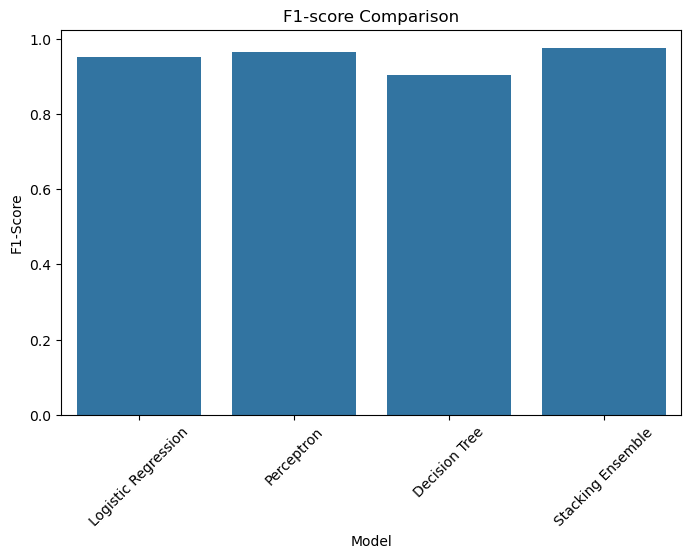

In [73]:
#Plot F1 Score Comparsion
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="F1-Score"
)

plt.xticks(rotation=45)

plt.title("F1-score Comparison")

plt.show()

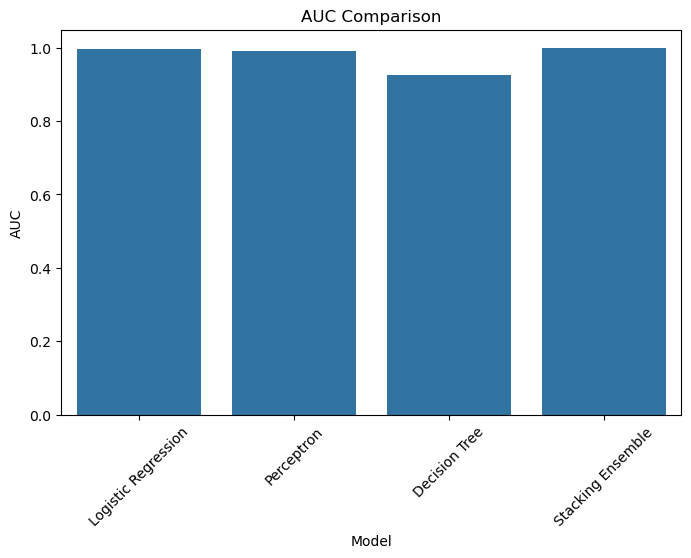

In [76]:
#plot AUC score comparsion
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="AUC"
)

plt.xticks(rotation=45)

plt.title("AUC Comparison")

plt.show()

## Conclusion (what i learned)

# Conclusion

In this project, a stacking ensemble classification model was developed using the Breast Cancer  Dataset from Kaggle.

Three Level-0 (base) models were trained:

- Logistic Regression
- Perceptron
- Decision Tree

Their predictions were combined using a Level-1 Logistic Regression meta-model.

The performance of each model was evaluated using F1-score and AUC.

## Observations

- Logistic Regression achieved good performance because the dataset contains numerical features that can be effectively separated using a linear decision boundary.

- The Perceptron model was fast and simple, but its performance can be limited because it can only learn linear patterns.

- The Decision Tree model can learn complex relationships, but it may be affected by overfitting because it creates decision rules from the training data.

- The Stacking Ensemble combines the strengths of multiple base models. The meta-model learns how to use the predictions from Logistic Regression, Perceptron, and Decision Tree to make a final prediction.

## Final Result

Based on the comparison of F1-score and AUC, the best-performing model was selected.

The stacking approach demonstrated how combining different machine learning models can improve prediction performance and provide a more robust classification system.

Dataset
   ↓
EDA
   ↓
Preprocessing
   ↓
Base Models
   ↓
Stacking Ensemble
   ↓
Evaluation
   ↓
Conclusion